In [88]:
# Instalar mrmr-selection se não estiver instalado
# !pip install mrmr-selection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from scipy.stats import pearsonr
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import log_loss as sk_log_loss, matthews_corrcoef
from sklearn.linear_model import LogisticRegression

# Seleção de features mRMR
try:
    from mrmr import mrmr_classif
    MRMR_AVAILABLE = True
except ImportError:
    MRMR_AVAILABLE = False
    print("⚠️ mRMR não está instalado. Instale com: pip install mrmr-selection")

# Sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import VarianceThreshold

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


In [58]:
# Carregar o dataset DoS
dos_path = Path("../data/processed/DoS_with_gap_2.csv")
df = pd.read_csv(dos_path)

print(f"📊 Shape do dataset: {df.shape}")
print(f"📝 Colunas: {df.shape[1]}")
print(f"📋 Registros: {df.shape[0]}")
print(f"\n🏷️ Distribuição do Label ('type'):")
print(df['type'].value_counts())

📊 Shape do dataset: (94625, 67)
📝 Colunas: 67
📋 Registros: 94625

🏷️ Distribuição do Label ('type'):
type
normal    49111
DoS       45514
Name: count, dtype: int64


In [59]:
# Selecionar apenas features numéricas
num_df = df.select_dtypes(include=['int64', 'float64'])

# Colunas a remover (irrelevantes para detecção de ataques)
colunas_para_remover = [
    'frame.time_delta_displayed', 'frame.time_epoch', 'frame.time_invalid', 
    'frame.time_relative', 'tcp.srcport', 'tcp.dstport', 
    'frame.coloring_rule.name', 'frame.coloring_rule.string', 
    'frame.comment', 'frame.comment.expert', 'frame.encap_type', 
    'frame.file_off', 'frame.ignored', 'frame.incomplete', 
    'frame.interface_id', 'frame.interface_name', 'frame.link_nr', 
    'frame.marked', 'frame.md5_hash', 'frame.number', 'frame.offset_shift',
    'mqtt.msgid', 'mqtt.username', 'mqtt.passwd', 
    'mqtt.willmsg', 'mqtt.willtopic'
]

# Remover colunas existentes no dataframe
colunas_existentes = [c for c in colunas_para_remover if c in num_df.columns]
X = num_df.drop(columns=colunas_existentes, errors='ignore')

# Tratar valores ausentes e infinitos
X = X.fillna(0)
X = X.replace([np.inf, -np.inf], 0)

# Encode do label (target)
le = LabelEncoder()
y = le.fit_transform(df['type'])

print(f"✅ Features numéricas após limpeza: {X.shape[1]}")
print(f"🎯 Classes: {le.classes_}")
print(f"📊 Shape X: {X.shape}, y: {y.shape}")

✅ Features numéricas após limpeza: 29
🎯 Classes: ['DoS' 'normal']
📊 Shape X: (94625, 29), y: (94625,)


In [60]:
print(X.shape[1])

29


In [61]:
df.describe()

,frame.time_delta,frame.time_delta_displayed,frame.time_epoch,frame.time_invalid,frame.time_relative,tcp.srcport,tcp.dstport,frame.cap_len,frame.coloring_rule.name,frame.coloring_rule.string,frame.comment,frame.comment.expert,frame.encap_type,frame.file_off,frame.ignored,frame.incomplete,frame.interface_id,frame.interface_name,frame.len,frame.link_nr,frame.marked,frame.md5_hash,frame.number,frame.offset_shift,mqtt.clientid_len,mqtt.conack.flags.reserved,mqtt.conack.flags.sp,mqtt.conack.val,mqtt.conflag.cleansess,mqtt.conflag.passwd,mqtt.conflag.qos,mqtt.conflag.reserved,mqtt.conflag.retain,mqtt.conflag.uname,mqtt.conflag.willflag,mqtt.dupflag,mqtt.kalive,mqtt.len,mqtt.msgid,mqtt.msgtype,mqtt.passwd,mqtt.passwd_len,mqtt.qos,mqtt.retain,mqtt.sub.qos,mqtt.suback.qos,mqtt.topic_len,mqtt.username,mqtt.username_len,mqtt.willmsg,mqtt.willmsg_len,mqtt.willtopic,mqtt.willtopic_len,publish_gap,connect_gap
count,94625.000000,94625.000000,9.462500e+04,0.0,94625.000000,88460.000000,88460.000000,94625.000000,0.0,0.0,0.0,0.0,94625.0,0.0,94625.0,0.0,0.0,0.0,94625.000000,0.0,94625.0,0.0,94625.000000,94625.0,323.000000,770.000000,770.000000,770.000000,323.0,323.0,323.0,323.0,323.0,323.0,323.0,38464.000000,323.000000,39535.000000,791.000000,39535.000000,0.0,0.0,38464.000000,38464.000000,4.0,4.0,38468.000000,0.0,0.0,0.0,0.0,0.0,0.0,37863.000000,323.000000
mean,0.012070,0.012070,1.522236e+09,NaN,446.566717,33486.654951,18929.162243,972.513828,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,972.513828,NaN,0.0,NaN,32312.706769,0.0,36.547988,0.579221,0.376623,49.579221,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.004888,57.910217,157.806399,21559.549937,3.110864,NaN,NaN,0.029586,0.010321,0.0,0.0,409.030207,NaN,NaN,NaN,NaN,NaN,NaN,-0.020804,-0.820997
std,0.144073,0.144073,2.455989e+02,NaN,245.598869,24462.816507,23776.322786,663.725442,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,663.725442,NaN,0.0,NaN,17165.823732,0.0,3.975080,0.494005,0.484854,47.368045,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.069742,9.484279,29.595162,6521.075375,1.094848,NaN,NaN,0.268086,0.101070,0.0,0.0,2511.835279,NaN,NaN,NaN,NaN,NaN,NaN,301.477019,199.410587
min,0.000000,0.000000,1.522235e+09,NaN,0.000000,22.000000,22.000000,38.000000,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,38.000000,NaN,0.0,NaN,1.000000,0.0,13.000000,0.000000,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,15.000000,0.000000,2.000000,0.000000,NaN,NaN,0.000000,0.000000,0.0,0.0,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,-724.757576,-569.721189
25%,0.000062,0.000062,1.522236e+09,NaN,229.586461,443.000000,1883.000000,77.000000,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,77.000000,NaN,0.0,NaN,16461.000000,0.0,37.000000,0.000000,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,60.000000,160.000000,14661.000000,3.000000,NaN,NaN,0.000000,0.000000,0.0,0.0,62.000000,NaN,NaN,NaN,NaN,NaN,NaN,-258.398193,-0.261201
50%,0.000130,0.000130,1.522236e+09,NaN,483.413649,51962.000000,1883.000000,1514.000000,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,1514.000000,NaN,0.0,NaN,35375.000000,0.0,37.000000,1.000000,0.000000,51.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,60.000000,164.000000,24932.000000,3.000000,NaN,NaN,0.000000,0.000000,0.0,0.0,63.000000,NaN,NaN,NaN,NaN,NaN,NaN,-0.002190,0.000111
75%,0.000781,0.000781,1.522236e+09,NaN,693.616637,52269.000000,51903.000000,1514.000000,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,1514.000000,NaN,0.0,NaN,48323.000000,0.0,38.000000,1.000000,1.000000,101.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,60.000000,168.000000,25965.000000,3.000000,NaN,NaN,0.000000,0.000000,0.0,0.0,63.000000,NaN,NaN,NaN,NaN,NaN,NaN,258.350707,0.233117
max,5.628732,5.628732,1.522236e+09,NaN,942.053725,60952.000000,60952.000000,1514.000000,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,1514.000000,NaN,0.0,NaN,62327.000000,0.0,38.000000,1.000000,1.000000,116.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,60.000000,182.000000,30765.000000,14.000000,NaN,NaN,3.000000,1.000000,0.0,0.0,29044.000000,NaN,NaN,NaN,NaN,NaN,NaN,728.722162,574.268817


In [62]:
list(X.keys())


['frame.time_delta',
 'frame.cap_len',
 'frame.len',
 'mqtt.clientid_len',
 'mqtt.conack.flags.reserved',
 'mqtt.conack.flags.sp',
 'mqtt.conack.val',
 'mqtt.conflag.cleansess',
 'mqtt.conflag.passwd',
 'mqtt.conflag.qos',
 'mqtt.conflag.reserved',
 'mqtt.conflag.retain',
 'mqtt.conflag.uname',
 'mqtt.conflag.willflag',
 'mqtt.dupflag',
 'mqtt.kalive',
 'mqtt.len',
 'mqtt.msgtype',
 'mqtt.passwd_len',
 'mqtt.qos',
 'mqtt.retain',
 'mqtt.sub.qos',
 'mqtt.suback.qos',
 'mqtt.topic_len',
 'mqtt.username_len',
 'mqtt.willmsg_len',
 'mqtt.willtopic_len',
 'publish_gap',
 'connect_gap']

In [63]:
if MRMR_AVAILABLE:
    K = 15 

x_mrmr = X.copy()
y_series = pd.Series(y, name ='target')

print(f"Executando mRMR para selecionar {K} features")

#Retornar a lista de features em ordem de importância 
mrmr_selected_features = mrmr_classif(X=x_mrmr, y=y_series, K=K)

print(f" Top {K} Features por mRMR com o novo dataset:")
for i, feature in enumerate(mrmr_selected_features, 1):
    print(f"  {i:2d}. {feature}")


Executando mRMR para selecionar 15 features


100%|██████████| 15/15 [00:02<00:00,  6.05it/s]

 Top 15 Features por mRMR com o novo dataset:
   1. mqtt.len
   2. mqtt.dupflag
   3. mqtt.msgtype
   4. mqtt.kalive
   5. frame.cap_len
   6. frame.len
   7. mqtt.topic_len
   8. frame.time_delta
   9. mqtt.qos
  10. mqtt.clientid_len
  11. mqtt.retain
  12. mqtt.conack.flags.reserved
  13. mqtt.conflag.cleansess
  14. mqtt.conack.val
  15. mqtt.conack.flags.sp


In [64]:
print(X.shape[1])

29


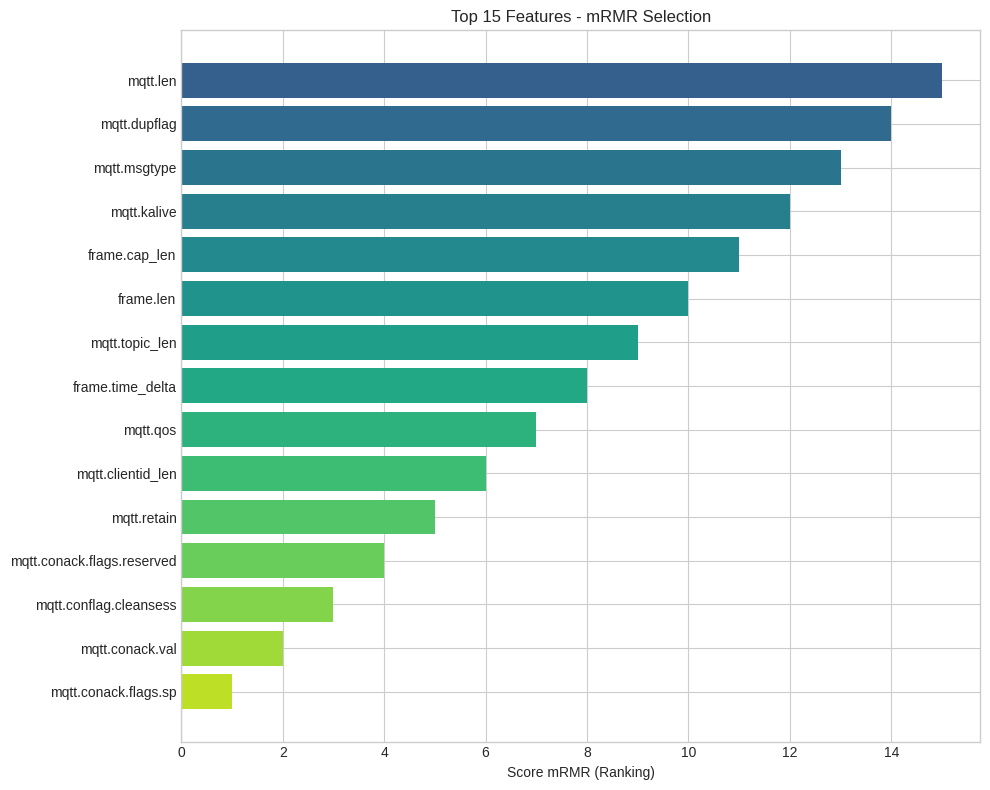

In [65]:
if mrmr_selected_features:
    #Criar dataframe com ranking
    mrmr_ranking = pd.DataFrame({
        'rank': range(1, len(mrmr_selected_features) + 1),
        'feature': mrmr_selected_features
    })

#Plotar ranking
    fig, ax = plt.subplots(figsize=(10,8))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(mrmr_selected_features)))
    
    bars = ax.barh(range(len(mrmr_selected_features)), 
                   range(len(mrmr_selected_features), 0, -1),
                   color=colors)
    
    ax.set_yticks(range(len(mrmr_selected_features)))
    ax.set_yticklabels(mrmr_selected_features)
    ax.set_xlabel('Score mRMR (Ranking)')
    ax.set_title(f'Top {len(mrmr_selected_features)} Features - mRMR Selection', fontsize=12)
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

In [66]:
print(X.shape[1])

29


In [67]:
# Validar: Comparar modelo com todas features vs features mRMR
if mrmr_selected_features:
    # Dividir dados
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    
    X_train_mrmr = X_train[mrmr_selected_features]
    X_test_mrmr = X_test[mrmr_selected_features]
    
    print(f"📊 Treinando modelo com {len(mrmr_selected_features)} features mRMR...")
    rf_mrmr = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_mrmr.fit(X_train_mrmr, y_train)
    acc_mrmr = accuracy_score(y_test, rf_mrmr.predict(X_test_mrmr))

    rf_mrmr.fit(X_train_mrmr, y_train)

    #Aplicando as previsões
    y_pred = rf_mrmr.predict(X_test_mrmr)

    #Probabilidade 
    y_proba = rf_mrmr.predict_proba(X_test_mrmr)

    logloss_mrmr = sk_log_loss(y_test, y_proba)
    
    # Resultado
    print(f"\n{'='*50}")
    print(f"📈 RESULTADOS DA VALIDAÇÃO")
    print(f"{'='*50}")
    print(f"🔹 Features mRMR ({len(mrmr_selected_features)}): Acurácia = {acc_mrmr:.4f}")
    print(f"{'='*50}")
    print(f"Log Loss: {logloss_mrmr:.4f}")
    print(f"{'='*50}")
    print(f"📉 Redução de features: {X.shape[1]} → {len(mrmr_selected_features)} ({(1-len(mrmr_selected_features)/X.shape[1])*100:.1f}% menos)")

📊 Treinando modelo com 15 features mRMR...

📈 RESULTADOS DA VALIDAÇÃO
🔹 Features mRMR (15): Acurácia = 0.9736
Log Loss: 0.0785
📉 Redução de features: 29 → 15 (48.3% menos)


In [68]:
y_pred = rf_mrmr.predict(X_test_mrmr)
recall = recall_score(y_test, y_pred, average='weighted')
print(f"🔹 Recall mRMR ({len(mrmr_selected_features)} features): {recall:.4f}")



🔹 Recall mRMR (15 features): 0.9736


In [69]:
from sklearn.feature_selection import SelectKBest, f_classif

# Usar variáveis já existentes no notebook
X_fisher = X.copy()
y_fisher = y_series.to_numpy().ravel() if 'y_series' in globals() else np.asarray(y).ravel()

# Limpeza básica para evitar erro no f_classif
X_fisher = X_fisher.replace([np.inf, -np.inf], 0).fillna(0)

# Remover colunas constantes (evita score NaN)
valid_cols = X_fisher.columns[X_fisher.nunique() > 1]
X_fisher = X_fisher[valid_cols]

# Calcular Fisher Score para todas as features
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_fisher, y_fisher)

fisher_scores = pd.DataFrame({
    'Feature': X_fisher.columns,
    'Fisher Score': selector.scores_
}).dropna().sort_values(by='Fisher Score', ascending=False)

print(fisher_scores)

                       Feature   Fisher Score
10                    mqtt.len  253627.762331
11                mqtt.msgtype  125052.893691
1                frame.cap_len    9213.156609
2                    frame.len    9213.156609
14              mqtt.topic_len    1095.339480
12                    mqtt.qos     504.545683
4   mqtt.conack.flags.reserved     485.999890
6              mqtt.conack.val     438.508080
13                 mqtt.retain     432.135446
9                  mqtt.kalive     331.287883
3            mqtt.clientid_len     322.233041
5         mqtt.conack.flags.sp     314.918826
7       mqtt.conflag.cleansess     310.249436
8                 mqtt.dupflag     203.694852
0             frame.time_delta     138.610829
16                 connect_gap       2.230366
15                 publish_gap       0.000074


In [70]:
mrmr_log_reg = LogisticRegression(random_state=42, max_iter=1000)
mrmr_log_reg.fit(X_train_mrmr, y_train)

y_pred_log_reg = mrmr_log_reg.predict(X_test_mrmr)
y_proba_log_reg = mrmr_log_reg.predict_proba(X_test_mrmr)

acc_log_reg = accuracy_score(y_test, y_pred_log_reg)

print(f"🔹 Regressão Logística (mRMR): Acurácia = {acc_log_reg:.4f}")


🔹 Regressão Logística (mRMR): Acurácia = 0.9260


In [71]:
y_pred = rf_mrmr.predict(X_test_mrmr)

precision_weighted = precision_score(y_test, y_pred, average='weighted')
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')
print(f"Precision weighted: {precision_weighted:.4f}")
print(f"Precision macro: {precision_macro:.4f}")
print(f"Recall weighted: {recall_weighted:.4f}")
print(f"Recall macro: {recall_macro:.4f}")
print(f"F1 macro: {f1_macro:.4f}")



Precision weighted: 0.9738
Precision macro: 0.9742
Recall weighted: 0.9736
Recall macro: 0.9731
F1 macro: 0.9735


🔍 INVESTIGAÇÃO: Treino vs Teste
📊 TREINO:
  Accuracy: 0.9792
  Precision (macro): 0.9799
  Recall (macro): 0.9787
  F1 (macro): 0.9792

📊 TESTE:
  Accuracy: 0.9736
  Precision (macro): 0.9742
  Recall (macro): 0.9731
  F1 (macro): 0.9735

🔍 INVESTIGAÇÃO: Matriz de Confusão

Matriz de Confusão (Teste):
[[13119   535]
 [  215 14519]]

Classes: ['DoS' 'normal']


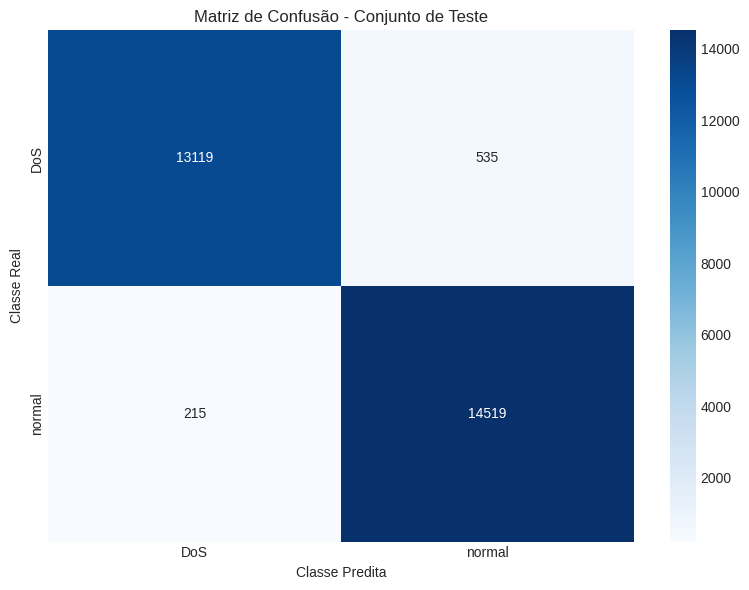


🔍 INVESTIGAÇÃO: Detalhes por Classe

Taxas de Erro por Classe:
  DoS: Erro = 3.92% (535/13654 erros)
  normal: Erro = 1.46% (215/14734 erros)

🔍 INVESTIGAÇÃO: Cross-Validation (5-fold)

Cross-Validation Scores (5-fold):
  accuracy            : 0.9739 ± 0.0010
    Fold scores: ['0.9727', '0.9731', '0.9740', '0.9743', '0.9754']
  precision_macro     : 0.9746 ± 0.0009
    Fold scores: ['0.9733', '0.9738', '0.9747', '0.9750', '0.9760']
  recall_macro        : 0.9734 ± 0.0010
    Fold scores: ['0.9722', '0.9725', '0.9734', '0.9738', '0.9749']
  f1_macro            : 0.9738 ± 0.0010
    Fold scores: ['0.9726', '0.9730', '0.9739', '0.9743', '0.9753']

🔍 INVESTIGAÇÃO: Features 'GAP' - Altamente Discriminativas?

Features de 'gap' selecionadas: []

Importância das Features Selecionadas:
               feature  importance
              mqtt.len    0.281063
        mqtt.topic_len    0.246238
          mqtt.msgtype    0.232005
             frame.len    0.089152
         frame.cap_len    0.081582


In [72]:
# ========== VERIFICAÇÃO 1: COMPARAR TREINO vs TESTE ==========
print("🔍 INVESTIGAÇÃO: Treino vs Teste")
print("=" * 60)

# Predições no TREINO
y_pred_train = rf_mrmr.predict(X_train_mrmr)
print("📊 TREINO:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"  Precision (macro): {precision_score(y_train, y_pred_train, average='macro'):.4f}")
print(f"  Recall (macro): {recall_score(y_train, y_pred_train, average='macro'):.4f}")
print(f"  F1 (macro): {f1_score(y_train, y_pred_train, average='macro'):.4f}")

print("\n📊 TESTE:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"  F1 (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")

# ========== VERIFICAÇÃO 2: MATRIZ DE CONFUSÃO ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Matriz de Confusão")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão (Teste):")
print(cm)
print("\nClasses:", le.classes_)

# Visualizar
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Matriz de Confusão - Conjunto de Teste')
ax.set_ylabel('Classe Real')
ax.set_xlabel('Classe Predita')
plt.tight_layout()
plt.show()

# ========== VERIFICAÇÃO 3: POR CLASSE ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Detalhes por Classe")
print("=" * 60)

print("\nTaxas de Erro por Classe:")
for i, class_name in enumerate(le.classes_):
    correct = cm[i, i]
    total = cm[i].sum()
    error_rate = 1 - (correct / total)
    print(f"  {class_name}: Erro = {error_rate*100:.2f}% ({cm[i].sum() - cm[i, i]}/{cm[i].sum()} erros)")

# ========== VERIFICAÇÃO 4: CROSS-VALIDATION ==========
from sklearn.model_selection import cross_validate

print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Cross-Validation (5-fold)")
print("=" * 60)

rf_cv = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
cv_results = cross_validate(rf_cv, X_train_mrmr, y_train, cv=5, 
                            scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'])

print("\nCross-Validation Scores (5-fold):")
for metric in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric:20s}: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"    Fold scores: {[f'{s:.4f}' for s in scores]}")

# ========== VERIFICAÇÃO 5: FEATURES COM MAIS GAP ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Features 'GAP' - Altamente Discriminativas?")
print("=" * 60)

# Features de gap aparecem nos selecionados?
gap_features = [f for f in mrmr_selected_features if 'gap' in f.lower()]
print(f"\nFeatures de 'gap' selecionadas: {gap_features}")

# Verificar importância
feature_importance_mrmr = pd.DataFrame({
    'feature': mrmr_selected_features,
    'importance': rf_mrmr.feature_importances_
}).sort_values('importance', ascending=False)

print("\nImportância das Features Selecionadas:")
print(feature_importance_mrmr.head(10).to_string(index=False))

## 5. Seleção de Features via Fisher's Score

O **Fisher's Score** mede a capacidade discriminativa de cada feature, calculando a razão entre a variância inter-classes e a variância intra-classes. Features com alto Fisher's Score são melhores para separar as classes.

$$F(f) = \frac{\sum_{c=1}^{C} n_c (\mu_c - \mu)^2}{\sum_{c=1}^{C} n_c \sigma_c^2}$$

Onde:
- $\mu_c$ = média da feature na classe $c$
- $\sigma_c$ = desvio padrão da feature na classe $c$
- $\mu$ = média global da feature
- $n_c$ = número de amostras na classe $c$


In [73]:
from sklearn.feature_selection import SelectKBest, f_classif

# Usar o dataset tratado já existente no notebook
X_fisher_input = x_mrmr.copy() if 'x_mrmr' in globals() else X.copy()
y_fisher_input = y_series.to_numpy().ravel() if 'y_series' in globals() else np.asarray(y).ravel()

# Limpar valores inválidos
X_fisher_input = X_fisher_input.replace([np.inf, -np.inf], 0).fillna(0)

# Remover features constantes para evitar scores NaN
valid_cols = X_fisher_input.columns[X_fisher_input.nunique() > 1]
X_fisher_input = X_fisher_input[valid_cols]

K_fisher = min(15, X_fisher_input.shape[1])
selector_top15 = SelectKBest(score_func=f_classif, k=K_fisher)
selector_top15.fit(X_fisher_input, y_fisher_input)

fisher_df = pd.DataFrame({
    'feature': X_fisher_input.columns,
    'fisher_score': selector_top15.scores_
}).dropna().sort_values('fisher_score', ascending=False)

selected_features = fisher_df.head(K_fisher)['feature'].tolist()
feature_names = selected_features

print(f"Top {K_fisher} features selecionadas:")
print(feature_names)

print(f"\n🏆 Top {K_fisher} Features por Fisher's Score:")
for i, (_, row) in enumerate(fisher_df.head(K_fisher).iterrows(), 1):
    print(f"  {i:2d}. {row['feature']}: {row['fisher_score']:.4f}")

Top 15 features selecionadas:
['mqtt.len', 'mqtt.msgtype', 'frame.cap_len', 'frame.len', 'mqtt.topic_len', 'mqtt.qos', 'mqtt.conack.flags.reserved', 'mqtt.conack.val', 'mqtt.retain', 'mqtt.kalive', 'mqtt.clientid_len', 'mqtt.conack.flags.sp', 'mqtt.conflag.cleansess', 'mqtt.dupflag', 'frame.time_delta']

🏆 Top 15 Features por Fisher's Score:
   1. mqtt.len: 253627.7623
   2. mqtt.msgtype: 125052.8937
   3. frame.cap_len: 9213.1566
   4. frame.len: 9213.1566
   5. mqtt.topic_len: 1095.3395
   6. mqtt.qos: 504.5457
   7. mqtt.conack.flags.reserved: 485.9999
   8. mqtt.conack.val: 438.5081
   9. mqtt.retain: 432.1354
  10. mqtt.kalive: 331.2879
  11. mqtt.clientid_len: 322.2330
  12. mqtt.conack.flags.sp: 314.9188
  13. mqtt.conflag.cleansess: 310.2494
  14. mqtt.dupflag: 203.6949
  15. frame.time_delta: 138.6108


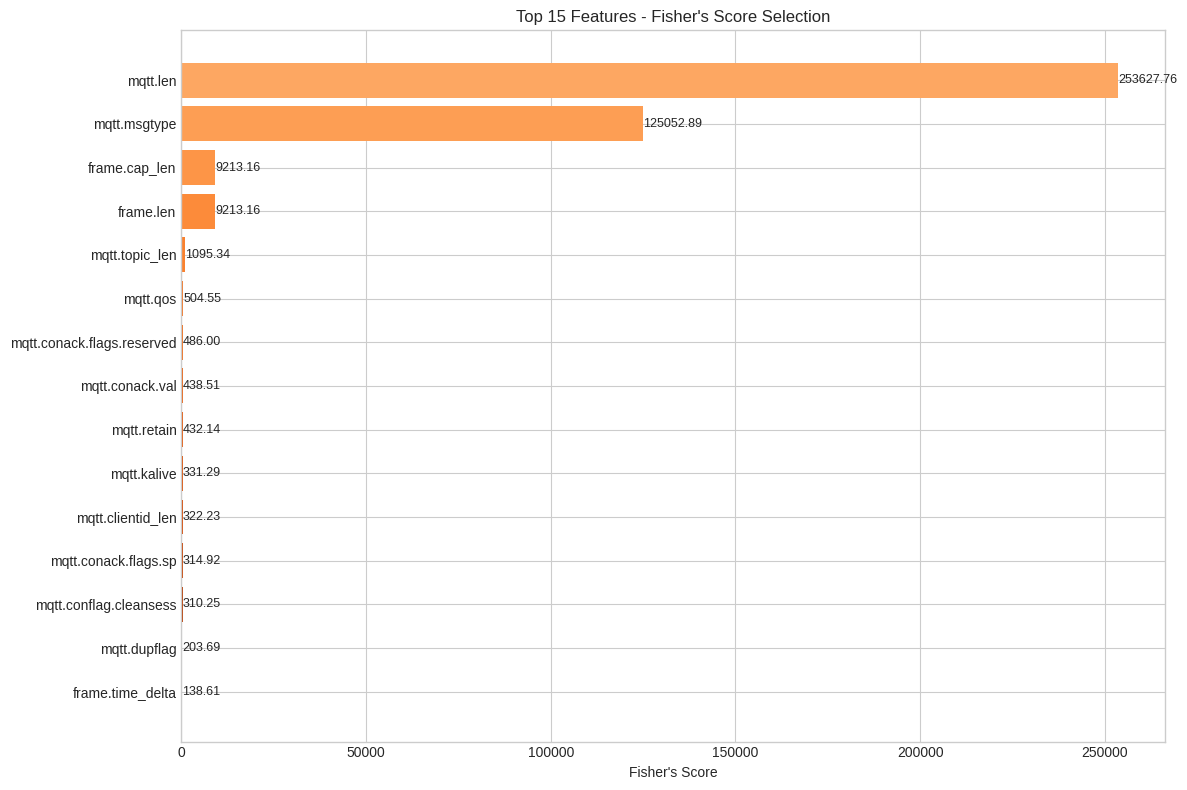

In [74]:
# Visualizar Fisher's Score
fig, ax = plt.subplots(figsize=(12, 8))

top_fisher = fisher_df.head(K_fisher)
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, K_fisher))

bars = ax.barh(range(K_fisher), top_fisher['fisher_score'].values, color=colors)
ax.set_yticks(range(K_fisher))
ax.set_yticklabels(top_fisher['feature'].values)
ax.set_xlabel("Fisher's Score")
ax.set_title(f"Top {K_fisher} Features - Fisher's Score Selection", fontsize=12)
ax.invert_yaxis()

# Adicionar valores nas barras
for i, (bar, score) in enumerate(zip(bars, top_fisher['fisher_score'].values)):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [75]:
# ========== REFATORADO: SEM VARIÁVEIS NÃO DEFINIDAS ==========
print("🔍 INVESTIGAÇÃO: Treino vs Teste (Fisher)")
print("=" * 60)

# Buscar variáveis com segurança (sem referência direta a nomes possivelmente inexistentes)
features_fisher_ref = (
    globals().get('fisher_features_cell16')
    or globals().get('selected_features')
    or globals().get('feature_names')
)

if not features_fisher_ref:
    raise ValueError("Nenhuma lista de features Fisher encontrada (fisher_features_cell16/selected_features/feature_names).")

X_train_base = (
    globals().get('X_train_fisher')
    or globals().get('X_train_eval')
    or globals().get('X_train_mrmr')
    or globals().get('X_train')
)

X_test_base = (
    globals().get('X_test_fisher')
    or globals().get('X_test_eval')
    or globals().get('X_test_mrmr')
    or globals().get('X_test')
)

if X_train_base is None or X_test_base is None:
    raise ValueError("Não foi possível localizar X_train/X_test base para avaliação Fisher.")

# Garantir mesmas colunas em treino e teste
features_fisher_ref = [f for f in features_fisher_ref if f in X_train_base.columns and f in X_test_base.columns]
if not features_fisher_ref:
    raise ValueError("Nenhuma feature em comum entre treino e teste para avaliação Fisher.")

X_train_eval = X_train_base[features_fisher_ref].copy()
X_test_eval = X_test_base[features_fisher_ref].copy()

# Modelo Fisher (reutiliza se existir; treina se não existir)
rf_fisher = globals().get('rf_fisher')
if rf_fisher is None:
    rf_fisher = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_fisher.fit(X_train_eval, y_train)

# Predições
y_pred_train = rf_fisher.predict(X_train_eval)
y_pred_fisher = rf_fisher.predict(X_test_eval)

print("📊 TREINO:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"  Precision (macro): {precision_score(y_train, y_pred_train, average='macro'):.4f}")
print(f"  Precision (micro): {precision_score(y_train, y_pred_train, average='micro'):.4f}")
print(f"  Recall (macro): {recall_score(y_train, y_pred_train, average='macro'):.4f}")
print(f"  F1 (macro): {f1_score(y_train, y_pred_train, average='macro'):.4f}")

print("\n📊 TESTE:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_fisher):.4f}")
print(f"  Precision (macro): {precision_score(y_test, y_pred_fisher, average='macro'):.4f}")
print(f"  Recall (macro): {recall_score(y_test, y_pred_fisher, average='macro'):.4f}")
print(f"  F1 (macro): {f1_score(y_test, y_pred_fisher, average='macro'):.4f}")

# ========== MATRIZ DE CONFUSÃO ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Matriz de Confusão")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred_fisher)
print("\nMatriz de Confusão (Teste):")
print(cm)
print("\nClasses:", le.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Matriz de Confusão - Conjunto de Teste (Fisher)')
ax.set_ylabel('Classe Real')
ax.set_xlabel('Classe Predita')
plt.tight_layout()
plt.show()

# ========== DETALHES POR CLASSE ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Detalhes por Classe")
print("=" * 60)

print("\nTaxas de Erro por Classe:")
for i, class_name in enumerate(le.classes_):
    total = cm[i].sum()
    correct = cm[i, i]
    error_rate = 1 - (correct / total) if total > 0 else 0.0
    print(f"  {class_name}: Erro = {error_rate*100:.2f}% ({total - correct}/{total} erros)")

# ========== CROSS-VALIDATION ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Cross-Validation (5-fold)")
print("=" * 60)

rf_cv = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
cv_results = cross_validate(
    rf_cv, X_train_eval, y_train, cv=5,
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
)

print("\nCross-Validation Scores (5-fold):")
for metric in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric:20s}: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"    Fold scores: {[f'{s:.4f}' for s in scores]}")

# ========== FEATURES 'GAP' + IMPORTÂNCIA ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Features 'GAP' - Fisher")
print("=" * 60)

gap_features = [f for f in features_fisher_ref if 'gap' in f.lower()]
print(f"\nFeatures de 'gap' selecionadas: {gap_features}")

feature_importance_fisher = pd.DataFrame({
    'feature': features_fisher_ref,
    'importance': rf_fisher.feature_importances_
}).sort_values('importance', ascending=False)

print("\nImportância das Features Selecionadas:")
print(feature_importance_fisher.head(10).to_string(index=False))


🔍 INVESTIGAÇÃO: Treino vs Teste (Fisher)


ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [76]:
def fisher_score(X, y):
    """
    Calcula o Fisher's Score para cada feature.
    
    Fisher's Score = variância inter-classes / variância intra-classes
    Features com maior score são mais discriminativas.
    """
    n_samples, n_features = X.shape
    classes = np.unique(y)
    n_classes = len(classes)
    
    # Média global de cada feature
    overall_mean = X.mean(axis=0)
    
    scores = np.zeros(n_features)
    
    for i in range(n_features):
        feature_values = X.iloc[:, i].values if hasattr(X, 'iloc') else X[:, i]
        
        # Variância inter-classes 
        between_class_var = 0
        # Variância intra-classes 
        within_class_var = 0
        
        for c in classes:
            class_mask = (y == c)
            n_c = np.sum(class_mask)
            
            if n_c > 0:
                class_mean = feature_values[class_mask].mean()
                class_var = feature_values[class_mask].var()
                
                between_class_var += n_c * (class_mean - overall_mean.iloc[i]) ** 2
                within_class_var += n_c * class_var
        
        # Evitar divisão por zero
        if within_class_var > 1e-10:
            scores[i] = between_class_var / within_class_var
        else:
            scores[i] = 0
    
    return scores

# Calcular Fisher's Score
print("🔍 Calculando Fisher's Score para cada feature...")
fisher_scores = fisher_score(X, y)

# Criar DataFrame com resultados
fisher_df = pd.DataFrame({
    'feature': X.columns,
    'fisher_score': fisher_scores
}).sort_values('fisher_score', ascending=False)

# Selecionar top K features no caso 15
K_fisher = 15
fisher_selected = fisher_df.head(K_fisher)['feature'].tolist()

print(f"\n🏆 Top {K_fisher} Features por Fisher's Score:")
for i, (_, row) in enumerate(fisher_df.head(K_fisher).iterrows(), 1):
    print(f"  {i:2d}. {row['feature']}: {row['fisher_score']:.4f}")

🔍 Calculando Fisher's Score para cada feature...

🏆 Top 15 Features por Fisher's Score:
   1. mqtt.len: 2.6804
   2. mqtt.msgtype: 1.3216
   3. frame.cap_len: 0.0974
   4. frame.len: 0.0974
   5. mqtt.topic_len: 0.0116
   6. mqtt.qos: 0.0053
   7. mqtt.conack.flags.reserved: 0.0051
   8. mqtt.conack.val: 0.0046
   9. mqtt.retain: 0.0046
  10. mqtt.kalive: 0.0035
  11. mqtt.clientid_len: 0.0034
  12. mqtt.conack.flags.sp: 0.0033
  13. mqtt.conflag.cleansess: 0.0033
  14. mqtt.dupflag: 0.0022
  15. frame.time_delta: 0.0015


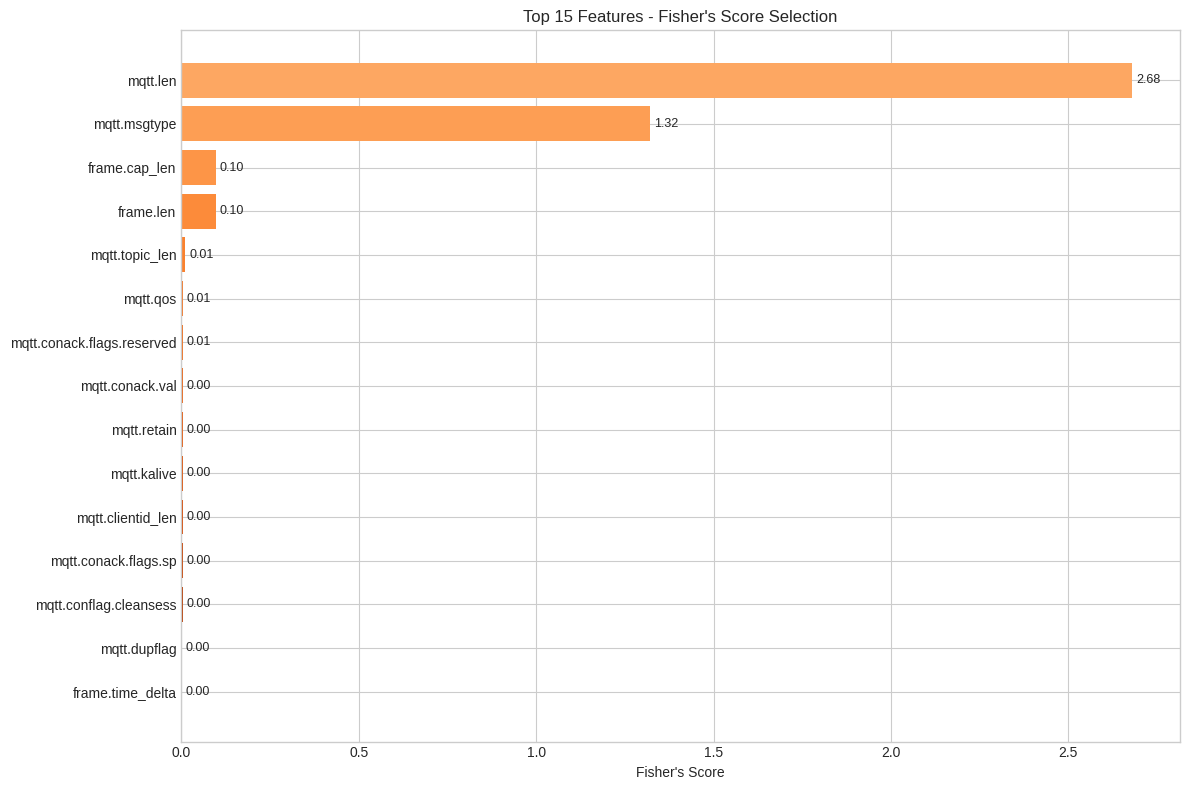

In [77]:
# Visualizar Fisher's Score
fig, ax = plt.subplots(figsize=(12, 8))

top_fisher = fisher_df.head(K_fisher)
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, K_fisher))

bars = ax.barh(range(K_fisher), top_fisher['fisher_score'].values, color=colors)
ax.set_yticks(range(K_fisher))
ax.set_yticklabels(top_fisher['feature'].values)
ax.set_xlabel("Fisher's Score")
ax.set_title(f"Top {K_fisher} Features - Fisher's Score Selection", fontsize=12)
ax.invert_yaxis()

# Adicionar valores nas barras
for i, (bar, score) in enumerate(zip(bars, top_fisher['fisher_score'].values)):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [78]:
# Validar: Comparar modelo com todas features vs features Fisher's Score
if fisher_selected:
    # Dividir dados
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    
    X_train_fisher = X_train[fisher_selected]
    X_test_fisher = X_test[fisher_selected]
    
    print(f"📊 Treinando modelo com {len(fisher_selected)} features Fisher...")
    rf_fisher = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_fisher.fit(X_train_fisher, y_train)
    acc_fisher = accuracy_score(y_test, rf_fisher.predict(X_test_fisher))
    
    # Resultado
    print(f"\n{'='*50}")
    print(f"📈 RESULTADOS DA VALIDAÇÃO")
    print(f"{'='*50}")
    print(f"🔹 Features Fisher's score ({len(fisher_selected)}): Acurácia = {acc_fisher:.4f}")
    print(f"{'='*50}")
    print(f"📉 Redução de features: {X.shape[1]} → {len(fisher_selected)} ({(1-len(fisher_selected)/X.shape[1])*100:.1f}% menos)")

📊 Treinando modelo com 15 features Fisher...

📈 RESULTADOS DA VALIDAÇÃO
🔹 Features Fisher's score (15): Acurácia = 0.9736
📉 Redução de features: 29 → 15 (48.3% menos)


In [79]:
# Validação: todas as features vs Fisher Score usando os dados/seleção da célula 16

X_base = x_mrmr.copy() if 'x_mrmr' in globals() else X.copy()
y_base = y_series.to_numpy().ravel() if 'y_series' in globals() else np.asarray(y).ravel()

fisher_features_cell16 = (
    fisher_selected if 'fisher_selected' in globals()
    else selected_features if 'selected_features' in globals()
    else feature_names
)

fisher_features_cell16 = [f for f in fisher_features_cell16 if f in X_base.columns]

if not fisher_features_cell16:
    raise ValueError("Nenhuma feature do Fisher Score foi encontrada em X_base.")

# manter variáveis esperadas nas próximas células
fisher_selected = fisher_features_cell16

X_train, X_test, y_train, y_test = train_test_split(
    X_base, y_base, test_size=0.3, random_state=42, stratify=y_base
)

X_train_fisher = X_train[fisher_selected].copy()
X_test_fisher = X_test[fisher_selected].copy()

rf_all = RandomForestClassifier(
    n_estimators=100, max_depth=15, random_state=42, n_jobs=-1
)
rf_fisher = RandomForestClassifier(
    n_estimators=100, max_depth=15, random_state=42, n_jobs=-1
)

rf_all.fit(X_train, y_train)
rf_fisher.fit(X_train_fisher, y_train)

y_pred_all = rf_all.predict(X_test)
y_proba_all = rf_all.predict_proba(X_test)

# manter y_pred e y_proba para compatibilidade com células abaixo
y_pred = rf_fisher.predict(X_test_fisher)
y_proba = rf_fisher.predict_proba(X_test_fisher)

comparacao_df = pd.DataFrame({
    "Modelo": ["Todas as features", f"Fisher Score ({len(fisher_selected)} features)"],
    "N_features": [X_train.shape[1], len(fisher_selected)],
    "Accuracy": [
        accuracy_score(y_test, y_pred_all),
        accuracy_score(y_test, y_pred)
    ],
    "Precision_macro": [
        precision_score(y_test, y_pred_all, average="macro"),
        precision_score(y_test, y_pred, average="macro")
    ],
    "Recall_macro": [
        recall_score(y_test, y_pred_all, average="macro"),
        recall_score(y_test, y_pred, average="macro")
    ],
    "F1_macro": [
        f1_score(y_test, y_pred_all, average="macro"),
        f1_score(y_test, y_pred, average="macro")
    ],
    "Log_loss": [
        sk_log_loss(y_test, y_proba_all),
        sk_log_loss(y_test, y_proba)
    ]
})

print("📊 Comparação: Todas as features vs Fisher Score")
print(comparacao_df.round(4).to_string(index=False))

print(f"\n📉 Redução de features: {X_train.shape[1]} → {len(fisher_selected)} "
      f"({(1 - len(fisher_selected) / X_train.shape[1]) * 100:.1f}% menos)")

📊 Comparação: Todas as features vs Fisher Score
                    Modelo  N_features  Accuracy  Precision_macro  Recall_macro  F1_macro  Log_loss
         Todas as features          29    0.9737           0.9743        0.9732    0.9736    0.0770
Fisher Score (15 features)          15    0.9736           0.9742        0.9731    0.9736    0.0774

📉 Redução de features: 29 → 15 (48.3% menos)


🔍 INVESTIGAÇÃO: Treino vs Teste
📊 TREINO:
  Accuracy: 0.9792
  Precision (macro): 0.9799
  Precision (micro): 0.9792
  Recall (macro): 0.9787
  F1 (macro): 0.9792

📊 TESTE:
  Accuracy: 0.9736
  Precision (macro): 0.9742
  Recall (macro): 0.9731
  F1 (macro): 0.9736

🔍 INVESTIGAÇÃO: Matriz de Confusão

Matriz de Confusão (Teste):
[[13114   540]
 [  209 14525]]

Classes: ['DoS' 'normal']


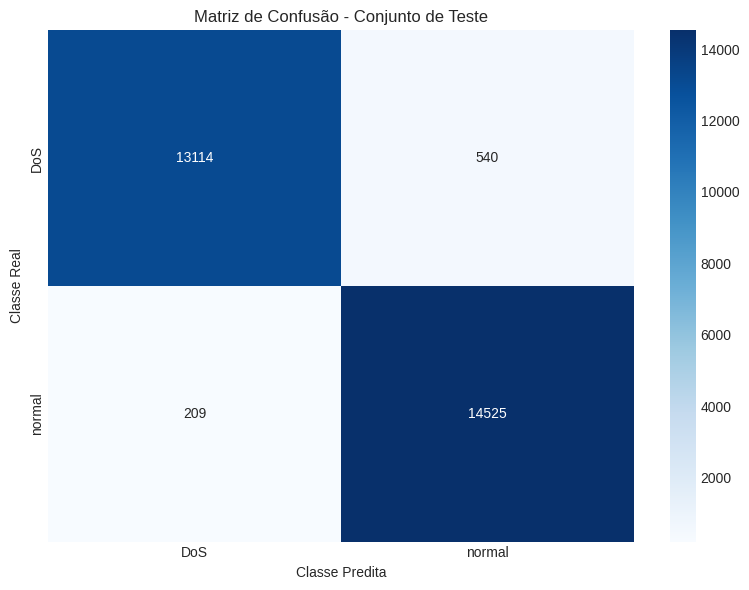


🔍 INVESTIGAÇÃO: Detalhes por Classe

Taxas de Erro por Classe:
  DoS: Erro = 3.95% (540/13654 erros)
  normal: Erro = 1.42% (209/14734 erros)

🔍 INVESTIGAÇÃO: Cross-Validation (5-fold)

Cross-Validation Scores (5-fold):
  accuracy            : 0.9738 ± 0.0009
    Fold scores: ['0.9728', '0.9728', '0.9737', '0.9746', '0.9752']
  precision_macro     : 0.9745 ± 0.0009
    Fold scores: ['0.9734', '0.9736', '0.9744', '0.9753', '0.9757']
  recall_macro        : 0.9733 ± 0.0010
    Fold scores: ['0.9722', '0.9723', '0.9732', '0.9740', '0.9747']
  f1_macro            : 0.9737 ± 0.0010
    Fold scores: ['0.9727', '0.9728', '0.9737', '0.9745', '0.9751']

🔍 INVESTIGAÇÃO: Features 'GAP' - Altamente Discriminativas?

Features de 'gap' selecionadas: []

Importância das Features Selecionadas:
             feature  importance
        mqtt.dupflag    0.260354
            mqtt.len    0.248391
       frame.cap_len    0.243585
         mqtt.kalive    0.092060
        mqtt.msgtype    0.082941
mqtt.conack.

In [80]:
# ========== VERIFICAÇÃO 1: COMPARAR TREINO vs TESTE ==========
print("🔍 INVESTIGAÇÃO: Treino vs Teste")
print("=" * 60)

# Predições no TREINO
y_pred_train = rf_fisher.predict(X_train_fisher)
print("📊 TREINO:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"  Precision (macro): {precision_score(y_train, y_pred_train, average='macro'):.4f}")
print(f"  Precision (micro): {precision_score(y_train, y_pred_train, average='micro'):.4f}")
print(f"  Recall (macro): {recall_score(y_train, y_pred_train, average='macro'):.4f}")
print(f"  F1 (macro): {f1_score(y_train, y_pred_train, average='macro'):.4f}")

print("\n📊 TESTE:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"  F1 (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")

# ========== VERIFICAÇÃO 2: MATRIZ DE CONFUSÃO ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Matriz de Confusão")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão (Teste):")
print(cm)
print("\nClasses:", le.classes_)

# Visualizar
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Matriz de Confusão - Conjunto de Teste')
ax.set_ylabel('Classe Real')
ax.set_xlabel('Classe Predita')
plt.tight_layout()
plt.show()

# ========== VERIFICAÇÃO 3: POR CLASSE ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Detalhes por Classe")
print("=" * 60)

print("\nTaxas de Erro por Classe:")
for i, class_name in enumerate(le.classes_):
    correct = cm[i, i]
    total = cm[i].sum()
    error_rate = 1 - (correct / total)
    print(f"  {class_name}: Erro = {error_rate*100:.2f}% ({cm[i].sum() - cm[i, i]}/{cm[i].sum()} erros)")

# ========== VERIFICAÇÃO 4: CROSS-VALIDATION ==========
from sklearn.model_selection import cross_validate

print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Cross-Validation (5-fold)")
print("=" * 60)

rf_cv = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
cv_results = cross_validate(rf_cv, X_train_fisher, y_train, cv=5, 
                            scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'])

print("\nCross-Validation Scores (5-fold):")
for metric in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric:20s}: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"    Fold scores: {[f'{s:.4f}' for s in scores]}")

# ========== VERIFICAÇÃO 5: FEATURES COM MAIS GAP ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Features 'GAP' - Altamente Discriminativas?")
print("=" * 60)

# Features de gap aparecem nos selecionados?
gap_features = [f for f in mrmr_selected_features if 'gap' in f.lower()]
print(f"\nFeatures de 'gap' selecionadas: {gap_features}")

# Verificar importância
feature_importance_fisher = pd.DataFrame({
    'feature': mrmr_selected_features,
    'importance': rf_fisher.feature_importances_
}).sort_values('importance', ascending=False)

print("\nImportância das Features Selecionadas:")
print(feature_importance_fisher.head(10).to_string(index=False))

### Selecao via low variance


In [81]:
# Para variância menor que 0.05
threshold = 0.05

selector = VarianceThreshold(threshold=threshold)
X_reduced = selector.fit_transform(X)

features_mantidas = X.columns[selector.get_support()].tolist()
features_removidas = X.columns[~selector.get_support()].tolist()

print(f"🔹 Features originais: {X.shape[1]}")
print(f"🔹 Features mantidas: {len(features_mantidas)}")
print(f"🔹 Features removidas: {len(features_removidas)}")


print(f"\n Features Mantidas:")
for i, f in enumerate(features_mantidas, 1):
    print(f"  {i:2d}. {f}")

print(f"\n❌ Features Removidas (variância < {threshold}):")
for i, f in enumerate(features_removidas, 1):
    print(f"  {i:2d}. {f}")

🔹 Features originais: 29
🔹 Features mantidas: 10
🔹 Features removidas: 19

 Features Mantidas:
   1. frame.cap_len
   2. frame.len
   3. mqtt.clientid_len
   4. mqtt.conack.val
   5. mqtt.kalive
   6. mqtt.len
   7. mqtt.msgtype
   8. mqtt.topic_len
   9. publish_gap
  10. connect_gap

❌ Features Removidas (variância < 0.05):
   1. frame.time_delta
   2. mqtt.conack.flags.reserved
   3. mqtt.conack.flags.sp
   4. mqtt.conflag.cleansess
   5. mqtt.conflag.passwd
   6. mqtt.conflag.qos
   7. mqtt.conflag.reserved
   8. mqtt.conflag.retain
   9. mqtt.conflag.uname
  10. mqtt.conflag.willflag
  11. mqtt.dupflag
  12. mqtt.passwd_len
  13. mqtt.qos
  14. mqtt.retain
  15. mqtt.sub.qos
  16. mqtt.suback.qos
  17. mqtt.username_len
  18. mqtt.willmsg_len
  19. mqtt.willtopic_len


## Seleção de features completa e validação com 4 modelos
Aplicação dos métodos usados no notebook de correlação com gaps (mRMR, Fisher, correlação com o alvo, baixa variância, ExtraTrees, SVC L1 e LassoCV) no dataset atual, avaliando RandomForest, Regressão Logística, KNN e Decision Tree para cada conjunto de features.

In [89]:
# Função auxiliar para avaliar um conjunto de features com 6 classificadores
def evaluate_feature_set(name, features, X, y, test_size=0.3, random_state=42):
    if features is None or len(features) == 0:
        print(f"⚠️ {name}: lista de features vazia, pulando.")
        return pd.DataFrame()
    filtered = [f for f in features if f in X.columns]
    if len(filtered) == 0:
        print(f"⚠️ {name}: nenhuma feature filtrada encontrada em X, pulando.")
        return pd.DataFrame()
    
    X_sel = X[filtered].copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X_sel, y, test_size=test_size, stratify=y, random_state=random_state
    )
    
    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=150, max_depth=None, random_state=random_state, n_jobs=-1
        ),
        "LogisticRegression": make_pipeline(
            StandardScaler(), LogisticRegression(max_iter=1000, n_jobs=-1, solver="lbfgs")
        ),
        "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7)),
        "DecisionTree": DecisionTreeClassifier(random_state=random_state),
        "NaiveBayes": GaussianNB(),
        "SVM_RBF": make_pipeline(StandardScaler(), SVC(kernel='rbf', C=3, gamma='scale', probability=True, random_state=random_state))
    }
    
    rows = []
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        try:
            y_proba = model.predict_proba(X_test)
        except Exception:
            y_proba = None
        rows.append({
            "feature_set": name,
            "n_features": len(filtered),
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "mcc": matthews_corrcoef(y_test, y_pred),
            "log_loss": sk_log_loss(y_test, y_proba) if y_proba is not None else np.nan
        })
    
    return pd.DataFrame(rows)

In [83]:
# Seleção por correlação com o alvo (Pearson)
K_generic = min(15, X.shape[1])
def select_top_pearson(X, y, k=15):
    rows = []
    for col in X.columns:
        if X[col].std() == 0:
            continue
        corr, p_value = pearsonr(X[col], y)
        rows.append((col, corr, p_value))
    pearson_df = pd.DataFrame(rows, columns=["feature", "corr", "p_value"])
    pearson_df["abs_corr"] = pearson_df["corr"].abs()
    return pearson_df.sort_values("abs_corr", ascending=False).head(min(k, len(pearson_df)))
    
pearson_results = select_top_pearson(X, y, k=K_generic)
pearson_selected = pearson_results["feature"].tolist()
print(f"Top {len(pearson_selected)} features por correlação com o alvo:")
print(pearson_selected)

Top 15 features por correlação com o alvo:
['mqtt.len', 'mqtt.msgtype', 'frame.cap_len', 'frame.len', 'mqtt.topic_len', 'mqtt.qos', 'mqtt.conack.flags.reserved', 'mqtt.conack.val', 'mqtt.retain', 'mqtt.kalive', 'mqtt.clientid_len', 'mqtt.conack.flags.sp', 'mqtt.conflag.cleansess', 'mqtt.dupflag', 'frame.time_delta']


In [84]:
# Seleção por importância do ExtraTrees
K_importance = min(15, X.shape[1])
extratrees = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)
extratrees.fit(X, y)
extratree_df = pd.DataFrame({
    "feature": X.columns,
    "importance": extratrees.feature_importances_
}).sort_values("importance", ascending=False)
extratree_selected = extratree_df.head(K_importance)["feature"].tolist()
print(f"Top {len(extratree_selected)} features por ExtraTrees:")
print(extratree_selected)

Top 15 features por ExtraTrees:
['mqtt.len', 'mqtt.msgtype', 'frame.cap_len', 'frame.len', 'mqtt.topic_len', 'frame.time_delta', 'publish_gap', 'mqtt.kalive', 'mqtt.clientid_len', 'mqtt.qos', 'mqtt.conflag.cleansess', 'mqtt.conack.flags.reserved', 'mqtt.retain', 'mqtt.conack.val', 'mqtt.conack.flags.sp']


In [85]:
# Seleção via LinearSVC com regularização L1
K_linear = min(15, X.shape[1])
svc_pipeline = make_pipeline(StandardScaler(), LinearSVC(C=0.1, penalty='l1', dual=False, random_state=42))
svc_pipeline.fit(X, y)
svc_model = svc_pipeline.named_steps['linearsvc']
svc_coef_abs = np.abs(svc_model.coef_).mean(axis=0)
svc_df = pd.DataFrame({
    "feature": X.columns,
    "coef_abs": svc_coef_abs
}).sort_values("coef_abs", ascending=False)
svc_selected = svc_df.head(K_linear)["feature"].tolist()
print(f"Top {len(svc_selected)} features por SVC (L1):")
print(svc_selected)

Top 15 features por SVC (L1):
['mqtt.len', 'frame.len', 'mqtt.topic_len', 'mqtt.kalive', 'mqtt.msgtype', 'mqtt.conflag.cleansess', 'mqtt.conack.flags.reserved', 'frame.cap_len', 'frame.time_delta', 'mqtt.clientid_len', 'mqtt.qos', 'connect_gap', 'publish_gap', 'mqtt.conflag.uname', 'mqtt.conflag.retain']


In [86]:
# Seleção via LassoCV
K_lasso = min(15, X.shape[1])
scaler_lasso = StandardScaler()
X_scaled = scaler_lasso.fit_transform(X)
lasso_cv = LassoCV(cv=5, random_state=42, n_jobs=-1)
lasso_cv.fit(X_scaled, y)
lasso_df = pd.DataFrame({
    "feature": X.columns,
    "coef_abs": np.abs(lasso_cv.coef_)
}).sort_values("coef_abs", ascending=False)
lasso_selected = lasso_df.head(K_lasso)["feature"].tolist()
print(f"Top {len(lasso_selected)} features por LassoCV:")
print(lasso_selected)

Top 15 features por LassoCV:
['mqtt.len', 'frame.cap_len', 'mqtt.msgtype', 'mqtt.kalive', 'mqtt.topic_len', 'mqtt.conack.flags.reserved', 'mqtt.qos', 'frame.time_delta', 'mqtt.dupflag', 'mqtt.conack.flags.sp', 'mqtt.retain', 'mqtt.clientid_len', 'frame.len', 'mqtt.conflag.uname', 'mqtt.conflag.retain']


In [87]:
# Avaliar todos os seletores com RF, Regressão Logística, KNN e Decision Tree
feature_sets = {
    "mrmr": mrmr_selected_features if 'mrmr_selected_features' in globals() else [],
    "fisher": fisher_selected if 'fisher_selected' in globals() else [],
    "pearson": pearson_selected if 'pearson_selected' in globals() else [],
    "low_variance": features_mantidas if 'features_mantidas' in globals() else [],
    "extratrees": extratree_selected if 'extratree_selected' in globals() else [],
    "linear_svc_l1": svc_selected if 'svc_selected' in globals() else [],
    "lasso_cv": lasso_selected if 'lasso_selected' in globals() else []
}
all_results = []
for name, feats in feature_sets.items():
    res = evaluate_feature_set(name, feats, X, y)
    if not res.empty:
        all_results.append(res)
        print(f"✅ {name}: {len(feats)} features avaliadas")
    else:
        print(f"⏭️ {name}: sem resultados")
        
if all_results:
    results_df = pd.concat(all_results).sort_values(["feature_set", "model"]).reset_index(drop=True)
    display(results_df)
    best_per_set = results_df.loc[results_df.groupby('feature_set')["accuracy"].idxmax()]
    print("\n🏁 Melhor modelo por conjunto de features (ordem por acurácia):")
    print(best_per_set.sort_values("accuracy", ascending=False).to_string(index=False))
else:
    print("Nenhum resultado gerado. Revise as listas de features.")

✅ mrmr: 15 features avaliadas
✅ fisher: 15 features avaliadas
✅ pearson: 15 features avaliadas
✅ low_variance: 10 features avaliadas
✅ extratrees: 15 features avaliadas
✅ linear_svc_l1: 15 features avaliadas
✅ lasso_cv: 15 features avaliadas


,feature_set,n_features,model,accuracy,precision_macro,recall_macro,f1_macro,mcc,log_loss
0,extratrees,15,DecisionTree,0.966570,0.966704,0.966354,0.966510,0.933058,0.683287
1,extratrees,15,KNN,0.969529,0.969860,0.969189,0.969465,0.939048,0.369848
2,extratrees,15,LogisticRegression,0.925919,0.935510,0.923263,0.925095,0.858686,0.169155
3,extratrees,15,RandomForest,0.969177,0.969525,0.968825,0.969111,0.938350,0.302042
4,fisher,15,DecisionTree,0.966535,0.966674,0.966315,0.966474,0.932988,0.683356
5,fisher,15,KNN,0.969459,0.969776,0.969126,0.969395,0.938902,0.368964
6,fisher,15,LogisticRegression,0.926025,0.935647,0.923365,0.925200,0.858925,0.169197
7,fisher,15,RandomForest,0.969248,0.969591,0.968898,0.969182,0.938489,0.304142
8,lasso_cv,15,DecisionTree,0.966535,0.966674,0.966315,0.966474,0.932988,0.683356
9,lasso_cv,15,KNN,0.969529,0.969851,0.969194,0.969466,0.939045,0.368865



🏁 Melhor modelo por conjunto de features (ordem por acurácia):
  feature_set  n_features model  accuracy  precision_macro  recall_macro  f1_macro      mcc  log_loss
   extratrees          15   KNN  0.969529         0.969860      0.969189  0.969465 0.939048  0.369848
     lasso_cv          15   KNN  0.969529         0.969851      0.969194  0.969466 0.939045  0.368865
       fisher          15   KNN  0.969459         0.969776      0.969126  0.969395 0.938902  0.368964
      pearson          15   KNN  0.969459         0.969776      0.969126  0.969395 0.938902  0.368964
         mrmr          15   KNN  0.969459         0.969776      0.969126  0.969395 0.938902  0.368964
linear_svc_l1          15   KNN  0.969424         0.969726      0.969100  0.969361 0.938826  0.370192
 low_variance          10   KNN  0.966887         0.967896      0.966211  0.966789 0.934106  0.384155


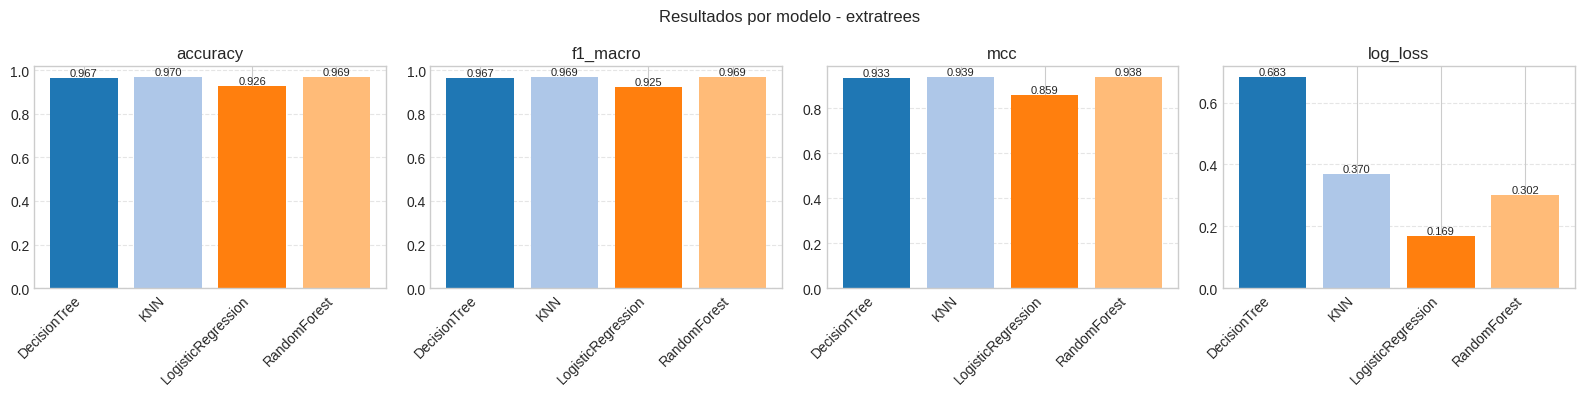

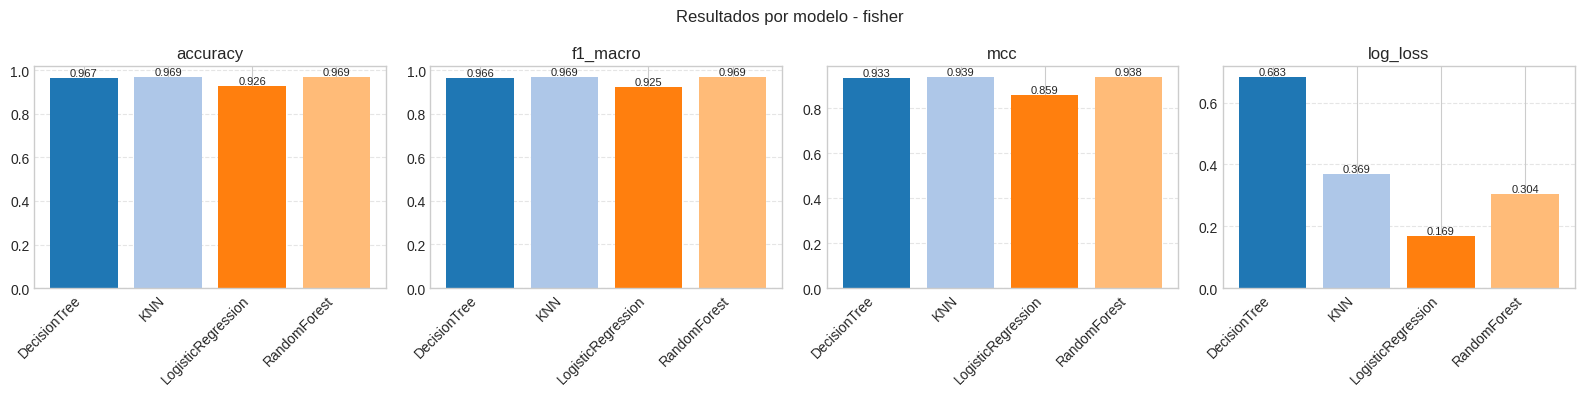

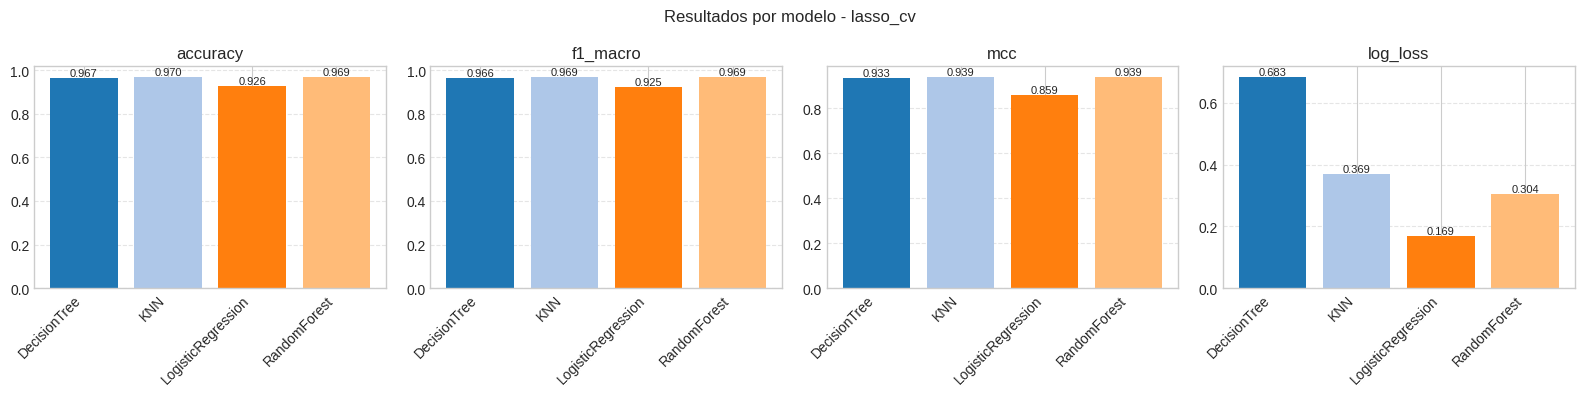

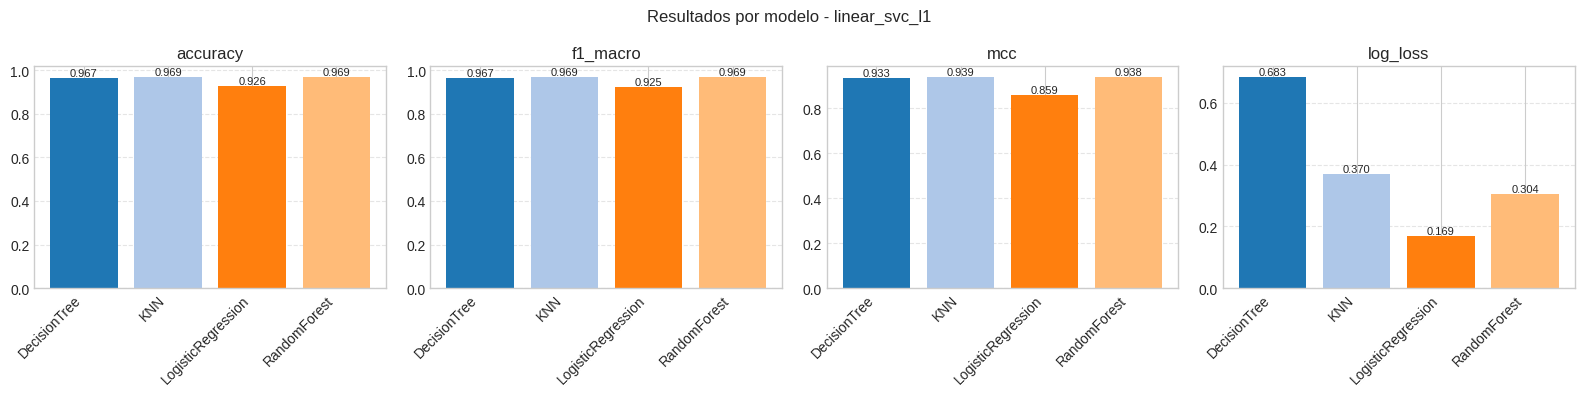

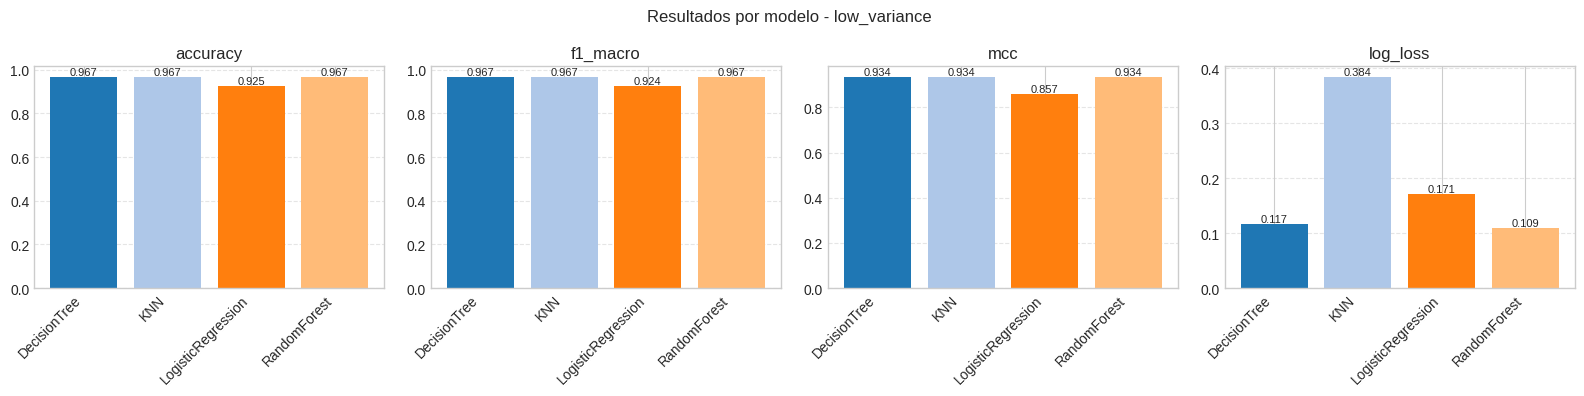

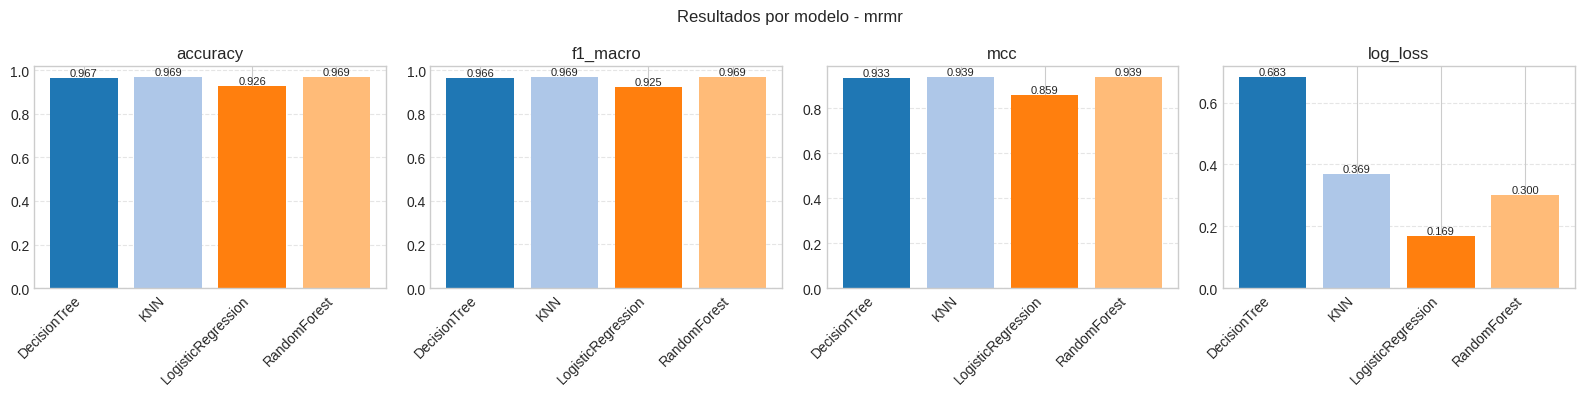

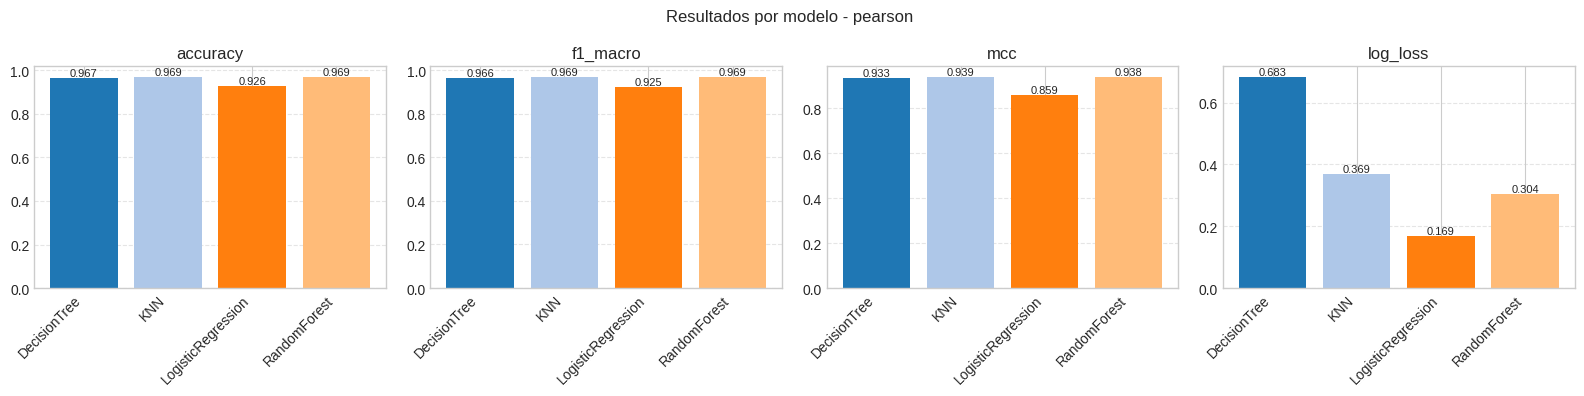

In [92]:
# Gráficos por método: métricas principais (accuracy, f1_macro, mcc, log_loss)
if 'results_df' in globals():
    metrics_to_plot = ["accuracy", "f1_macro", "mcc", "log_loss"]
    for method in results_df['feature_set'].unique():
        subset = results_df[results_df['feature_set'] == method]
        fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 4), sharex=False)
        fig.suptitle(f"Resultados por modelo - {method}")
        for ax, metric in zip(axes, metrics_to_plot):
            bars = ax.bar(subset['model'], subset[metric], color=plt.cm.tab20.colors[:len(subset)])
            ax.set_title(metric)
            ax.set_xticklabels(subset['model'], rotation=45, ha='right')
            ax.grid(True, axis='y', linestyle='--', alpha=0.5)
            # Adicionar valores sobre as barras
            for bar, value in zip(bars, subset[metric]):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:.3f}", ha='center', va='bottom', fontsize=8)
        plt.tight_layout()
        plt.show()
else:
    print("results_df não encontrado; execute a célula de avaliação primeiro.")

frame.cap_len                 7
frame.len                     7
mqtt.clientid_len             7
mqtt.topic_len                7
mqtt.msgtype                  7
mqtt.len                      7
mqtt.kalive                   7
mqtt.conack.flags.reserved    6
frame.time_delta              6
mqtt.qos                      6
mqtt.conack.flags.sp          5
mqtt.conflag.cleansess        5
mqtt.retain                   5
mqtt.conack.val               5
mqtt.dupflag                  4
publish_gap                   3
connect_gap                   2
mqtt.conflag.uname            2
mqtt.conflag.retain           2
Name: times_selected, dtype: int64


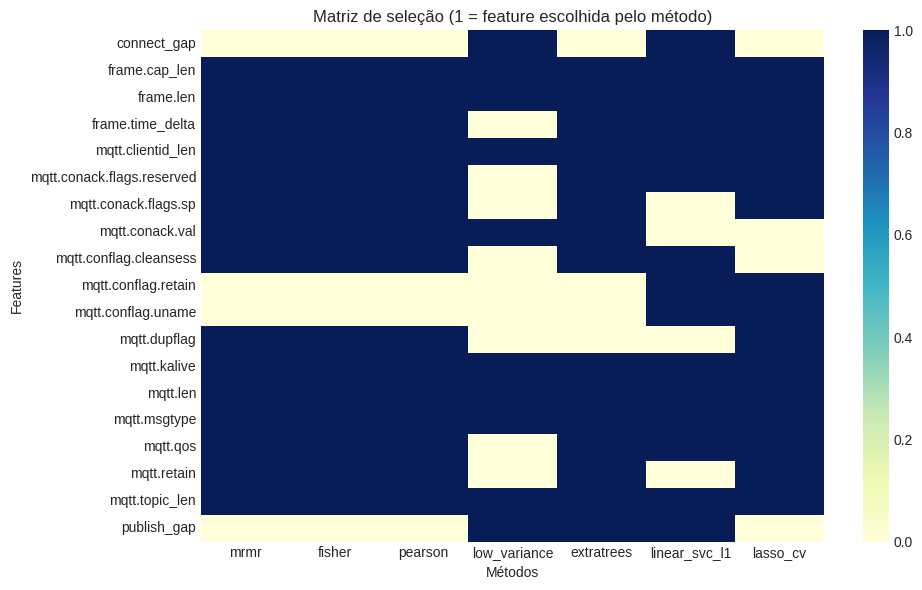

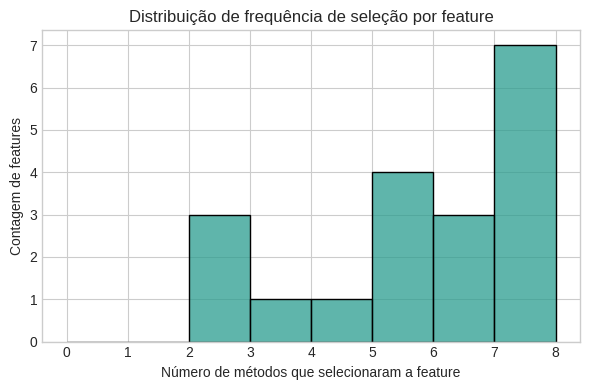

In [93]:
# Matriz de seleção de features (frequência por método)
selection_map = {
    "mrmr": set(feature_sets.get("mrmr", [])),
    "fisher": set(feature_sets.get("fisher", [])),
    "pearson": set(feature_sets.get("pearson", [])),
    "low_variance": set(feature_sets.get("low_variance", [])),
    "extratrees": set(feature_sets.get("extratrees", [])),
    "linear_svc_l1": set(feature_sets.get("linear_svc_l1", [])),
    "lasso_cv": set(feature_sets.get("lasso_cv", []))
}
all_feats = sorted({f for feats in selection_map.values() for f in feats})
selection_df = pd.DataFrame({m: [1 if f in feats else 0 for f in all_feats] for m, feats in selection_map.items()}, index=all_feats)
selection_df['times_selected'] = selection_df.sum(axis=1)
print(selection_df['times_selected'].sort_values(ascending=False).head(20))
plt.figure(figsize=(10, max(6, len(all_feats)*0.15)))
sns.heatmap(selection_df.drop(columns=['times_selected']), cmap='YlGnBu', cbar=True, annot=False)
plt.title('Matriz de seleção (1 = feature escolhida pelo método)')
plt.xlabel('Métodos')
plt.ylabel('Features')
plt.tight_layout()
plt.show()
plt.figure(figsize=(6, 4))
sns.histplot(selection_df['times_selected'], bins=range(0, selection_df['times_selected'].max()+2), kde=False, color='#2a9d8f')
plt.title('Distribuição de frequência de seleção por feature')
plt.xlabel('Número de métodos que selecionaram a feature')
plt.ylabel('Contagem de features')
plt.tight_layout()
plt.show()